# Modelos de referencia y experimentos iniciales

Este cuaderno corresponde a la segunda etapa del proyecto y a la primera parte del objetivo específico 2: implementar el flujo de validación, entrenar los modelos de referencia y realizar los experimentos iniciales que ponen a prueba las hipótesis formuladas en el análisis exploratorio. La búsqueda completa de modelos, con las formulaciones ordinales y los demás algoritmos, se realiza en la etapa siguiente.

Las hipótesis provienen de las secciones 8 a 10 del análisis exploratorio:

| Hipótesis | Enunciado | Comparación |
|---|---|---|
| H1 | El modelo de referencia supera al azar | QWK del modelo entrenado con el conjunto de referencia frente a su distribución con etiquetas permutadas |
| H2 | El conjunto principal alcanza un QWK mayor que el de referencia, con una ganancia que se espera pequeña | Principal frente a referencia |
| H3 | Si el conjunto principal mejora, la mejora proviene de la actigrafía | Principal frente a principal sin actigrafía |
| H4 | El conjunto complementario mejora frente al principal | Complementario frente a principal |

Para que las diferencias reflejen la información que aporta cada conjunto y no el algoritmo, todas las comparaciones usan las mismas dos configuraciones fijas, una regresión logística multinomial y un modelo de gradient boosting, sobre los mismos participantes y las mismas particiones. El cuaderno sigue este orden: datos y conjuntos de variables, esquema de validación, métricas y controles, preprocesamiento, modelo de referencia, experimentos iniciales, desempeño por nivel de severidad y conclusión.

Como en el análisis exploratorio, todas las salidas son agregadas. Las predicciones por participante se usan solo para calcular métricas y no se muestran.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.dummy import DummyClassifier

from piu_severity.config import FIGURES_DIR, RANDOM_SEED
from piu_severity.data.clean import clean_values
from piu_severity.data.load import list_actigraphy_ids, load_train
from piu_severity.evaluation.metrics import SII_LEVELS, as_levels
from piu_severity.evaluation.validation import (
    N_OUTER_REPEATS,
    N_OUTER_SPLITS,
    aggregate_repeats,
    inner_cv,
    outer_splits,
    permutation_null,
    permutation_p_value,
    run_nested_cv,
    split_level_counts,
    summarize_by_repeat,
)
from piu_severity.features.actigraphy import (
    ACTIGRAPHY_FEATURES,
    load_actigraphy_summary,
)
from piu_severity.features.build import build_analytic_dataset
from piu_severity.features.groups import (
    TARGET_COLUMN,
    column_group,
    experiment_feature_sets,
    is_excluded,
    is_instrument_season,
)
from piu_severity.features.preprocessing import build_preprocessor, column_types
from piu_severity.models.pipelines import make_boosting_search, make_logistic_search
from piu_severity.visualization.figures import save_figure

In [2]:
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

FIGURAS = FIGURES_DIR / "02_experimentos_iniciales"

NIVELES_SII = {0: "ninguno", 1: "leve", 2: "moderado", 3: "severo"}
NOMBRES_CONJUNTOS = {
    "reference": "referencia",
    "main": "principal",
    "main_without_actigraphy": "principal sin actigrafía",
    "complementary": "complementario",
}

## 1. Datos y conjuntos de variables

El conjunto de datos analítico se construye con el paquete del proyecto, con los mismos pasos de la sección 10 del análisis exploratorio: depuración de los valores inválidos y recorte a los máximos del protocolo de FitnessGram, fusión de los totales de PAQ-A y PAQ-C e incorporación de las variables de actigrafía de las series utilizables. Como estas reglas son fijas y no se ajustan con los datos, se aplican una sola vez, antes de la validación cruzada.

Los predictores se organizan en dos niveles, definidos en el análisis exploratorio. El primero son los **grupos**, que clasifican cada variable según lo que mide; cada variable pertenece a un solo grupo:

| Grupo | Qué mide |
|---|---|
| Demográfico | Edad, sexo y temporada de inscripción |
| Físico | Medidas antropométricas y signos vitales, aptitud física (FitnessGram), composición corporal (bioimpedancia), actividad física autorreportada (PAQ) y actividad física medida con actigrafía |
| Complementario | Alteraciones del sueño (SDS), funcionamiento global (CGAS) y horas diarias de uso de computador e internet |

El segundo nivel son los **conjuntos**, que combinan grupos y son los que se usan para entrenar los modelos:

| Conjunto | Grupos que incluye | Pregunta que responde |
|---|---|---|
| Referencia | Demográfico | ¿Cuánto se puede estimar el SII solo con la edad, el sexo y la temporada de inscripción? |
| Principal sin actigrafía | Demográfico y físico, sin las variables de actigrafía | ¿Cuánto aportan las variables físicas tabulares por encima de las demográficas? |
| Principal | Demográfico y físico | ¿Cuánto aportan los indicadores físicos por encima de las variables demográficas? Es la pregunta central del proyecto |
| Complementario | Demográfico, físico y complementario | ¿Cuánto cambia el desempeño al añadir medidas psicológicas, conductuales y de uso de internet? |

Los conjuntos de referencia, principal y complementario provienen de la formulación del proyecto. El conjunto principal sin actigrafía se agrega para aislar el aporte de la actigrafía, que es la hipótesis H3. El modelo de referencia es, por tanto, el modelo entrenado con el conjunto de referencia.

Esta sección construye el conjunto de datos analítico y los cuatro conjuntos de variables. Se verifica que los conjuntos estén anidados, que no incluyan el identificador ni las columnas del PCIAT y que su composición coincida con la del análisis exploratorio.

In [3]:
train = load_train()
etiquetados = train[train[TARGET_COLUMN].notna()].reset_index(drop=True)

analitico = build_analytic_dataset(
    clean_values(etiquetados), load_actigraphy_summary(list_actigraphy_ids())
)
y = as_levels(analitico[TARGET_COLUMN])
conjuntos = experiment_feature_sets(analitico.columns)
columnas_actigrafia = list(ACTIGRAPHY_FEATURES.values())

assert len(analitico) == len(etiquetados)
assert analitico["id"].is_unique
assert not any(
    is_excluded(c) or is_instrument_season(c)
    for columnas in conjuntos.values()
    for c in columnas
)
assert (
    set(conjuntos["reference"])
    <= set(conjuntos["main_without_actigraphy"])
    <= set(conjuntos["main"])
    <= set(conjuntos["complementary"])
)
assert set(conjuntos["main"]) - set(conjuntos["main_without_actigraphy"]) == set(
    columnas_actigrafia
)

distribucion_sii = (
    pd.Series(y)
    .map(NIVELES_SII)
    .value_counts()
    .reindex(NIVELES_SII.values())
    .rename_axis("SII")
    .to_frame("participantes")
)
distribucion_sii["%"] = (
    100 * distribucion_sii["participantes"] / distribucion_sii["participantes"].sum()
).round(1)
distribucion_sii

,participantes,%
SII,,
ninguno,1594,58.3
leve,730,26.7
moderado,378,13.8
severo,34,1.2


In [4]:
GRUPOS_ES = {
    "demographic": "demográficas",
    "physical": "físicas",
    "complementary": "complementarias",
}

composicion_conjuntos = pd.DataFrame(
    {
        NOMBRES_CONJUNTOS[nombre]: pd.Series(
            [GRUPOS_ES[column_group(c)] for c in columnas]
        ).value_counts()
        for nombre, columnas in conjuntos.items()
    }
).reindex(GRUPOS_ES.values()).fillna(0).astype(int).T
composicion_conjuntos["total"] = composicion_conjuntos.sum(axis="columns")
composicion_conjuntos["incluye actigrafía"] = [
    "sí" if set(columnas_actigrafia) <= set(columnas) else "no"
    for columnas in conjuntos.values()
]
composicion_conjuntos.index.name = "conjunto"

print(f"Participantes etiquetados: {len(analitico)}")
print(
    "Participantes con variables de actigrafía: "
    f"{int(analitico[columnas_actigrafia].notna().any(axis='columns').sum())}"
)
composicion_conjuntos

Participantes etiquetados: 2736
Participantes con variables de actigrafía: 823


,demográficas,físicas,complementarias,total,incluye actigrafía
conjunto,,,,,
referencia,3,0,0,3,no
principal,3,33,0,36,sí
principal sin actigrafía,3,30,0,33,no
complementario,3,33,3,39,sí


### Conclusión

El conjunto de datos analítico reproduce el del análisis exploratorio: contiene a los 2.736 participantes etiquetados, de los cuales 823 tienen variables de actigrafía, y conserva la distribución del SII (58,3 % ninguno, 26,7 % leve, 13,8 % moderado y 1,2 % severo, con 34 casos severos).

| Conjunto | Demográficas | Físicas | Complementarias | Total | Incluye actigrafía |
|---|---|---|---|---|---|
| Referencia | 3 | 0 | 0 | 3 | No |
| Principal sin actigrafía | 3 | 30 | 0 | 33 | No |
| Principal | 3 | 33 | 0 | 36 | Sí |
| Complementario | 3 | 33 | 3 | 39 | Sí |

Cada fila indica cuántas variables de cada grupo contiene el conjunto. Los cuatro conjuntos están anidados en el orden de la tabla y ninguno incluye el identificador, las columnas del PCIAT ni las temporadas de instrumento. Con esta estructura, cada hipótesis compara dos conjuntos que difieren en un solo bloque de variables: H2, todas las variables físicas; H3, solo la actigrafía; y H4, las variables complementarias.

## 2. Esquema de validación

Cada modelo requiere dos decisiones que deben tomarse con datos distintos: elegir sus hiperparámetros, como la intensidad de la regularización, y medir su desempeño en participantes que no vio durante el entrenamiento. Si ambas se hicieran con los mismos datos, el desempeño estimado sería optimista, porque los hiperparámetros elegidos serían los que mejor se ajustan precisamente a esos participantes. Para separarlas se usa validación cruzada anidada, que tiene dos niveles.

**Nivel externo: medición del desempeño.** Los 2.736 participantes se dividen en cinco partes de tamaño similar, estratificadas por SII para que cada parte conserve la proporción de cada nivel de severidad. Se hacen cinco vueltas: en cada una, una de las partes se aparta como partición de evaluación y las otras cuatro forman la partición de entrenamiento. Al terminar, cada participante se ha evaluado exactamente una vez.

**Nivel interno: elección de hiperparámetros.** Dentro de cada partición de entrenamiento externa, y solo con esos participantes, se repite el mismo procedimiento con tres partes. Cada combinación candidata de hiperparámetros se entrena con dos partes y se evalúa con la tercera, rotando tres veces, y se elige la de mejor QWK promedio. Con esa combinación, el modelo se reentrena con toda la partición de entrenamiento externa y se evalúa en la partición de evaluación externa, que no intervino en ninguna decisión de ajuste.

| Nivel | Qué participantes se dividen | Partes | Participantes para entrenar | Participantes para evaluar | Uso |
|---|---|---|---|---|---|
| Externo | Los 2.736 participantes | 5 | Alrededor de 2.189 (cuatro de las cinco partes) | Alrededor de 547 (una parte) | Medir el desempeño |
| Interno | Los participantes de entrenamiento de una partición externa | 3 | Alrededor de 1.459 (dos de las tres partes) | Alrededor de 730 (una parte) | Elegir los hiperparámetros |

El nivel externo se repite cinco veces, con una división distinta de los participantes en cada repetición; la repetición r usa la semilla base más r. Esto da 25 particiones externas y reduce la dependencia de los resultados respecto de una sola forma de dividir los datos. Como todas las configuraciones y todos los conjuntos de variables se evalúan sobre las mismas 25 particiones, las comparaciones entre ellos se pueden hacer de forma pareada, sobre los mismos participantes.

Esta sección construye las particiones y verifica tres propiedades: que cada participante se evalúe exactamente una vez en cada repetición, que la estratificación mantenga la proporción de cada nivel de SII y cuántos casos de cada nivel contiene cada partición de evaluación, externa e interna. Este último conteo condiciona la estabilidad de las métricas del nivel severo.

In [5]:
particiones = outer_splits(y)

for repeticion in range(N_OUTER_REPEATS):
    evaluados = np.concatenate([p.test for p in particiones if p.repeat == repeticion])
    assert np.array_equal(np.sort(evaluados), np.arange(len(y)))
assert all(np.intersect1d(p.train, p.test).size == 0 for p in particiones)

tamanos_evaluacion = pd.Series([len(p.test) for p in particiones])
print(
    f"Particiones externas: {len(particiones)} "
    f"({N_OUTER_SPLITS} particiones × {N_OUTER_REPEATS} repeticiones)"
)
print(
    "Participantes por partición externa de evaluación: "
    f"entre {tamanos_evaluacion.min()} y {tamanos_evaluacion.max()}"
)

Particiones externas: 25 (5 particiones × 5 repeticiones)
Participantes por partición externa de evaluación: entre 547 y 548


In [6]:
casos_externos = split_level_counts(particiones, y)

filas_internas = []
for particion in particiones:
    y_entrenamiento = y[particion.train]
    for _, evaluacion_interna in inner_cv().split(
        np.zeros(len(y_entrenamiento)), y_entrenamiento
    ):
        conteo = pd.Series(y_entrenamiento[evaluacion_interna]).value_counts()
        filas_internas.append(conteo.reindex(SII_LEVELS, fill_value=0))
casos_internos = pd.DataFrame(filas_internas)

casos_por_particion = pd.concat(
    {
        "partición externa": casos_externos.agg(["min", "mean", "max"]).T,
        "partición interna": casos_internos.agg(["min", "mean", "max"]).T,
    },
    axis="columns",
).rename(index=NIVELES_SII, columns={"min": "mínimo", "mean": "media", "max": "máximo"})
casos_por_particion.index.name = "SII"

print(f"Particiones internas de evaluación: {len(casos_internos)}")
casos_por_particion.round(1)

Particiones internas de evaluación: 75


partición externa               partición interna              
                    mínimo  media máximo            mínimo  media máximo
SII                                                                     
ninguno              318.0  318.8  319.0             425.0  425.1  426.0
leve                 146.0  146.0  146.0             194.0  194.7  195.0
moderado              75.0   75.6   76.0             100.0  100.8  101.0
severo                 6.0    6.8    7.0               9.0    9.1   10.0

### Conclusión

#### Verificación de las particiones

Se generaron 25 particiones externas: cinco particiones en cada una de las cinco repeticiones. Cumplen las dos verificaciones: en cada repetición, cada participante se evalúa exactamente una vez, y ninguna partición comparte participantes entre entrenamiento y evaluación. Cada partición externa de evaluación contiene 547 o 548 participantes.

#### Casos de cada nivel por partición

Hay dos tipos de partición de evaluación. Las **externas** (25) miden el desempeño final de cada modelo. Las **internas** (75, tres dentro de cada partición externa) se usan solo para elegir los hiperparámetros, y se forman con los participantes de entrenamiento de la partición externa.

| SII | Casos en cada partición externa | Casos en cada partición interna |
|---|---|---|
| Ninguno | 318 o 319 | Entre 425 y 426 |
| Leve | 146 | Entre 194 y 195 |
| Moderado | 75 o 76 | Entre 100 y 101 |
| Severo | 6 o 7 | Entre 9 y 10 |

La tabla se lee por filas: por ejemplo, cada partición externa contiene 6 o 7 participantes con SII severo. En todos los niveles, el número de casos varía como máximo en uno entre particiones, de modo que la estratificación es prácticamente exacta y las diferencias de desempeño entre particiones no se deben a cambios en la proporción de los niveles.

#### Consecuencias para la evaluación

El nivel severo es el que limita la estabilidad de las estimaciones. Con 6 o 7 casos por partición externa, el recall de ese nivel calculado en una sola partición solo puede variar en saltos de alrededor de 14 puntos porcentuales: detectar un caso más o un caso menos cambia el resultado en esa magnitud. Por eso las métricas, que se definen en la sección siguiente, se calculan de dos formas:

- **QWK, por partición.** Así se obtienen 25 valores que permiten comparar dos configuraciones de forma pareada, sobre los mismos participantes.
- **Recall por nivel, tasa de subestimación y matriz de confusión, sobre las predicciones acumuladas de cada repetición.** Como en cada repetición todos los participantes se evalúan una vez, estas métricas usan los 34 casos severos y no solo los 6 o 7 de una partición.

En la validación interna, cada partición de evaluación conserva 9 o 10 casos severos. La selección de hiperparámetros se apoya, por tanto, en más casos de los que tendría con cinco particiones internas (alrededor de 5), aunque sigue dependiendo de pocos participantes de ese nivel.

## 3. Métricas y controles de cordura

El desempeño se mide con cuatro métricas, definidas en la formulación del proyecto:

- **QWK (quadratic weighted kappa).** Mide la concordancia entre el nivel real y el estimado, y penaliza cada error en proporción al cuadrado de la distancia entre ambos niveles. Vale 1 con concordancia perfecta y 0 cuando la concordancia equivale a la esperada por azar, dadas las distribuciones de los niveles reales y estimados. Es la métrica principal.
- **Recall por nivel** (sensibilidad). Proporción de participantes de cada nivel que el modelo asigna a ese mismo nivel; en el nivel severo, por ejemplo, es la proporción de casos severos identificados como severos.
- **Tasa de subestimación.** Proporción de participantes con PIU moderado o severo a los que se asigna un nivel inferior al real; se reporta también solo para el nivel severo, donde equivale a 1 menos su recall, porque cualquier error con un caso severo consiste en asignarle un nivel inferior. Complementa al QWK, que penaliza igual sobrestimar que subestimar, cuando en un tamizaje el error más costoso es subestimar un caso moderado o severo.
- **Matriz de confusión.** Distribución de los niveles estimados para cada nivel real.

Como se definió en la sección anterior, el QWK se calcula en cada partición externa y se promedia dentro de cada repetición; las demás métricas se calculan sobre las predicciones acumuladas de cada repetición. En adelante, los resultados se reportan como media ± desviación estándar entre las cinco repeticiones.

Antes de entrenar modelos, el flujo de evaluación se verifica con dos clasificadores que no usan los predictores:

- **Clase mayoritaria.** Asigna a todos los participantes el nivel más frecuente en la partición de entrenamiento. Por construcción, su QWK es 0.
- **Aleatorio estratificado.** Asigna niveles al azar con las proporciones de la partición de entrenamiento. Su QWK esperado también es 0, aunque varía entre particiones.

Estos dos clasificadores cumplen dos funciones: verifican que la evaluación produzca los valores esperados para un modelo sin información, y constituyen el primer nivel de la jerarquía de modelos de referencia, que cualquier modelo útil debe superar.

In [7]:
CONTROLES = {
    "clase mayoritaria": DummyClassifier(strategy="most_frequent"),
    "aleatorio estratificado": DummyClassifier(
        strategy="stratified", random_state=RANDOM_SEED
    ),
}
X_referencia = analitico[conjuntos["reference"]]

resultados_controles = {
    nombre: run_nested_cv(modelo, X_referencia, y, particiones)
    for nombre, modelo in CONTROLES.items()
}

In [15]:
METRICAS_ES = {
    "qwk": "QWK",
    "recall_0": "recall ninguno",
    "recall_1": "recall leve",
    "recall_2": "recall moderado",
    "recall_3": "recall severo",
    "underestimation": "subestimación moderado o severo",
    "underestimation_severe": "subestimación severo",
}


def tabla_desempeno(resultados: dict) -> pd.DataFrame:
    """Resume cada modelo con la media y la desviación entre repeticiones."""
    filas = {}
    for nombre, (pliegues, predicciones) in resultados.items():
        agregado = aggregate_repeats(summarize_by_repeat(pliegues, predicciones))
        filas[nombre] = {
            (METRICAS_ES[metrica], estadistico): agregado.at[metrica, columna]
            for metrica in METRICAS_ES
            for estadistico, columna in [("media", "mean"), ("desv.", "std")]
        }
    tabla = pd.DataFrame(filas).T
    tabla.columns = pd.MultiIndex.from_tuples(tabla.columns)
    return tabla


tabla_controles = tabla_desempeno(resultados_controles)
qwk_por_particion = pd.DataFrame(
    {nombre: pliegues["qwk"] for nombre, (pliegues, _) in resultados_controles.items()}
).agg(["min", "max"]).T.rename(columns={"min": "QWK mínimo", "max": "QWK máximo"})

display(tabla_controles.round(3))
qwk_por_particion.round(3)

QWK        recall ninguno        recall leve         \
                        media  desv.          media  desv.       media  desv.   
clase mayoritaria        0.00  0.000          1.000  0.000       0.000  0.000   
aleatorio estratificado -0.01  0.022          0.586  0.011       0.273  0.021   

                        recall moderado        recall severo         \
                                  media  desv.         media  desv.   
clase mayoritaria                 0.000  0.000         0.000  0.000   
aleatorio estratificado           0.123  0.025         0.006  0.013   

                        subestimación moderado o severo         \
                                                  media  desv.   
clase mayoritaria                                 1.000  0.000   
aleatorio estratificado                           0.874  0.022   

                        subestimación severo         
                                       media  desv.  
clase mayoritaria                      1.000  0.000  
aleatorio estratificado                0.994  0.013

,QWK mínimo,QWK máximo
clase mayoritaria,0.000,0.000
aleatorio estratificado,-0.078,0.082


### Conclusión

Los dos controles producen los valores esperados para clasificadores sin información, lo que confirma que la evaluación sobre las particiones funciona correctamente.

| Métrica | Clase mayoritaria | Aleatorio estratificado |
|---|---|---|
| QWK | 0,000 ± 0,000 | −0,010 ± 0,022 |
| QWK por partición (mínimo y máximo) | 0,000 y 0,000 | −0,078 y 0,082 |
| Recall ninguno | 1,000 ± 0,000 | 0,586 ± 0,011 |
| Recall leve | 0,000 ± 0,000 | 0,273 ± 0,021 |
| Recall moderado | 0,000 ± 0,000 | 0,123 ± 0,025 |
| Recall severo | 0,000 ± 0,000 | 0,006 ± 0,013 |
| Subestimación moderado o severo | 1,000 ± 0,000 | 0,874 ± 0,022 |
| Subestimación severo | 1,000 ± 0,000 | 0,994 ± 0,013 |

- **Clase mayoritaria.** Asigna el nivel ninguno a todos los participantes: su recall es 1 en ese nivel y 0 en los demás, subestima a todos los participantes con PIU moderado o severo y su QWK es exactamente 0 en las 25 particiones.
- **Aleatorio estratificado.** Su recall en cada nivel coincide con la proporción de ese nivel en los datos (58,3 %, 26,7 %, 13,8 % y 1,2 %), como corresponde a asignaciones al azar con esas proporciones, y su QWK medio es prácticamente 0.

El control aleatorio establece además el margen de variación que produce el azar: sin ninguna información, el QWK de una sola partición varió entre −0,078 y 0,082. Una diferencia de esa magnitud entre dos modelos en una partición aislada no indica por sí sola una mejora, y por eso las comparaciones entre configuraciones se basan en las 25 diferencias pareadas.

Por último, un modelo sin información subestima a casi 9 de cada 10 participantes con PIU moderado o severo, porque la mayoría de sus asignaciones corresponden a los niveles más frecuentes. Ese es el punto de partida frente al cual se juzga la subestimación de los modelos entrenados, y justifica la ponderación de las clases durante el entrenamiento.

## 4. Preprocesamiento

Las dos configuraciones de los experimentos requieren un preprocesamiento distinto, definido en las secciones 4 a 6 del análisis exploratorio:

- **Regresión logística.** No admite valores faltantes y es sensible a la escala de las variables. Las variables numéricas se imputan con la mediana y se transforman con Yeo-Johnson y estandarización; las ordinales se imputan con la moda y se estandarizan, sin transformarlas, para conservar la distancia entre sus niveles; las binarias se imputan con la moda. Como la imputación asigna el mismo valor a todos los participantes sin datos, se agrega un indicador por instrumento que vale 1 cuando el participante no tiene ningún dato de ese instrumento. Así, el modelo puede distinguir un valor imputado de uno medido.
- **Gradient boosting.** Admite valores faltantes de forma nativa: en cada división del árbol, los participantes sin dato se envían a la rama que más reduce la pérdida. Por eso las variables se usan sin imputar ni transformar, y sin indicadores de ausencia, ya que el propio modelo aprende a tratar la ausencia.

En ambos casos, la temporada de inscripción se codifica con una variable binaria por categoría. Todos los parámetros del preprocesamiento (medianas, modas, transformaciones y estandarización) se ajustan solo con la partición de entrenamiento, dentro del mismo flujo que el modelo, y se aplican después a la partición de evaluación.

Esta sección aplica los dos preprocesamientos a cada conjunto de variables, ajustándolos con la partición de entrenamiento de la primera partición externa y transformando su partición de evaluación. Se verifica la composición de las columnas resultantes, el número de indicadores por conjunto y que la regresión logística no reciba valores faltantes.

In [9]:
PREPROCESAMIENTOS = {
    "regresión logística": ("linear", "simple"),
    "gradient boosting": ("tree", "native"),
}
particion_ejemplo = particiones[0]

filas = []
indicadores_por_conjunto = {}
for nombre, columnas in conjuntos.items():
    X = analitico[columnas]
    tipos = column_types(columnas)
    for configuracion, (familia, estrategia) in PREPROCESAMIENTOS.items():
        preprocesador = build_preprocessor(columnas, familia, estrategia)
        preprocesador.fit(X.iloc[particion_ejemplo.train])
        salida = preprocesador.transform(X.iloc[particion_ejemplo.test])
        indicadores = [c for c in salida.columns if c.startswith("missing_")]
        if indicadores:
            indicadores_por_conjunto[NOMBRES_CONJUNTOS[nombre]] = indicadores
        filas.append(
            {
                "conjunto": NOMBRES_CONJUNTOS[nombre],
                "configuración": configuracion,
                "numéricas": len(tipos["numeric"]),
                "binarias": len(tipos["binary"]),
                "ordinales": len(tipos["ordinal"]),
                "nominales": len(tipos["nominal"]),
                "columnas de temporada": sum(
                    c.startswith("Basic_Demos-Enroll_Season") for c in salida.columns
                ),
                "indicadores de ausencia": len(indicadores),
                "columnas de salida": salida.shape[1],
                "% de celdas faltantes en la salida": round(
                    100 * salida.isna().to_numpy().mean(), 1
                ),
            }
        )

composicion_preprocesamiento = pd.DataFrame(filas).set_index(
    ["conjunto", "configuración"]
)
composicion_preprocesamiento

numéricas  binarias  ordinales  \
conjunto                 configuración                                         
referencia               regresión logística          1         1          0   
                         gradient boosting            1         1          0   
principal                regresión logística         25         6          4   
                         gradient boosting           25         6          4   
principal sin actigrafía regresión logística         22         6          4   
                         gradient boosting           22         6          4   
complementario           regresión logística         27         6          5   
                         gradient boosting           27         6          5   

                                              nominales  \
conjunto                 configuración                    
referencia               regresión logística          1   
                         gradient boosting            1   
principal                regresión logística          1   
                         gradient boosting            1   
principal sin actigrafía regresión logística          1   
                         gradient boosting            1   
complementario           regresión logística          1   
                         gradient boosting            1   

                                              columnas de temporada  \
conjunto                 configuración                                
referencia               regresión logística                      4   
                         gradient boosting                        4   
principal                regresión logística                      4   
                         gradient boosting                        4   
principal sin actigrafía regresión logística                      4   
                         gradient boosting                        4   
complementario           regresión logística                      4   
                         gradient boosting                        4   

                                              indicadores de ausencia  \
conjunto                 configuración                                  
referencia               regresión logística                        0   
                         gradient boosting                          0   
principal                regresión logística                        5   
                         gradient boosting                          0   
principal sin actigrafía regresión logística                        4   
                         gradient boosting                          0   
complementario           regresión logística                        8   
                         gradient boosting                          0   

                                              columnas de salida  \
conjunto                 configuración                             
referencia               regresión logística                   6   
                         gradient boosting                     6   
principal                regresión logística                  44   
                         gradient boosting                    39   
principal sin actigrafía regresión logística                  40   
                         gradient boosting                    36   
complementario           regresión logística                  50   
                         gradient boosting                    42   

                                              % de celdas faltantes en la salida  
conjunto                 configuración                                            
referencia               regresión logística                                 0.0  
                         gradient boosting                                   0.0  
principal                regresión logística                                 0.0  
                         gradient boosting                                  31.1  
principal sin actigrafía regresió

In [10]:
with pd.option_context("display.max_colwidth", None):
    display(
        pd.Series(
            {
                conjunto: ", ".join(n.removeprefix("missing_") for n in nombres)
                for conjunto, nombres in indicadores_por_conjunto.items()
            },
            name="instrumentos con indicador de ausencia",
        ).to_frame()
    )

,instrumentos con indicador de ausencia
principal,"Physical, FGC, BIA, PAQ, Actigraphy"
principal sin actigrafía,"Physical, FGC, BIA, PAQ"
complementario,"CGAS, Physical, FGC, BIA, SDS, PreInt_EduHx, PAQ, Actigraphy"


### Conclusión

Los dos preprocesamientos producen las columnas esperadas en los cuatro conjuntos, y la composición por tipo coincide con la del análisis exploratorio: 27 numéricas, 6 binarias, 5 ordinales y 1 nominal en el conjunto complementario.

| Conjunto | Predictores de entrada | Columnas de salida, regresión logística | Columnas de salida, gradient boosting | Indicadores de ausencia | Celdas faltantes en la salida de gradient boosting |
|---|---|---|---|---|---|
| Referencia | 3 | 6 | 6 | 0 | 0,0 % |
| Principal sin actigrafía | 33 | 40 | 36 | 4 | 27,8 % |
| Principal | 36 | 44 | 39 | 5 | 31,1 % |
| Complementario | 39 | 50 | 42 | 8 | 29,5 % |

Cada fila resume cómo se transforma un conjunto en cada configuración. Las columnas de salida de gradient boosting son los predictores de entrada más tres columnas adicionales, porque la temporada de inscripción se convierte en cuatro variables binarias. La regresión logística agrega además un indicador por instrumento.

- **Indicadores de ausencia.** Se crean para los instrumentos que pueden faltar: medidas físicas, FitnessGram, bioimpedancia, PAQ y actigrafía en el conjunto principal; los mismos sin actigrafía en el principal sin actigrafía; y, en el complementario, además el SDS, el CGAS y las horas de uso de internet. Las variables demográficas (edad, sexo y temporada de inscripción) no tienen indicador porque están completas en todos los participantes: un indicador de ausencia valdría 0 para todos y no aportaría información. Por la misma razón, el conjunto de referencia, que solo contiene variables demográficas, no tiene indicadores.
- **Valores faltantes.** La salida de la regresión logística no contiene valores faltantes en ningún conjunto. En gradient boosting, entre el 27,8 % y el 31,1 % de las celdas siguen faltantes y llegan así al modelo, que las maneja de forma nativa. Esa proporción refleja la ausencia por bloques de los instrumentos descrita en el análisis exploratorio.

Como el preprocesamiento se ajusta con la partición de entrenamiento y solo se aplica a la de evaluación, los valores de imputación y los parámetros de las transformaciones no usan información de los participantes evaluados.

## 5. Modelo de referencia y prueba de H1

El modelo de referencia usa solo las tres variables demográficas: edad, sexo y temporada de inscripción. Se entrena con las dos configuraciones de los experimentos:

- **Regresión logística multinomial**, con el preprocesamiento lineal de la sección anterior. La intensidad de la regularización C se elige en la validación interna entre seis valores, de 0,001 a 100.
- **Gradient boosting** con manejo nativo de faltantes. En la validación interna se elige el número de iteraciones (100 o 300) y el número máximo de hojas por árbol (7 o 15), con una tasa de aprendizaje fija de 0,05.

Ambas ponderan las clases de forma inversamente proporcional a su frecuencia en cada partición de entrenamiento, y ambas eligen sus hiperparámetros por el QWK de la validación interna.

La hipótesis H1 plantea que el modelo de referencia supera al azar. Se pone a prueba con una prueba de permutación: las etiquetas de SII se reordenan al azar, lo que rompe cualquier relación con los predictores pero conserva la distribución de los niveles, y se repite el mismo procedimiento de entrenamiento y evaluación. Con 200 permutaciones se obtiene la distribución del QWK cuando no existe relación entre las variables y el SII. El valor p es la proporción de permutaciones que alcanzan un QWK igual o mayor que el observado, (1 + número de permutaciones con QWK igual o mayor) / (1 + 200). Para que el QWK observado y el de las permutaciones sean comparables, ambos se calculan con el mismo procedimiento: las cinco particiones de la primera repetición. La prueba se aplica a la regresión logística, porque repetir 200 veces la búsqueda de gradient boosting tiene un costo alto y H1 se refiere a la información de las variables demográficas, no al algoritmo.

In [11]:
CONFIGURACIONES = {
    "regresión logística": make_logistic_search,
    "gradient boosting": make_boosting_search,
}

resultados = {}
for configuracion, construir_modelo in CONFIGURACIONES.items():
    columnas = conjuntos["reference"]
    resultados[(configuracion, "reference")] = run_nested_cv(
        construir_modelo(columnas, n_jobs=-1), analitico[columnas], y, particiones
    )

In [12]:
def hiperparametros_elegidos(pliegues: pd.DataFrame) -> pd.Series:
    """Cuenta cuántas particiones externas eligieron cada combinación."""
    return (
        pliegues["best_params"]
        .map(
            lambda parametros: ", ".join(
                f"{clave.removeprefix('model__')} = {valor}"
                for clave, valor in parametros.items()
            )
        )
        .value_counts()
        .rename("particiones")
    )


modelos_referencia = {
    f"{configuracion} (referencia)": resultados[(configuracion, "reference")]
    for configuracion in CONFIGURACIONES
}
display(tabla_desempeno({**resultados_controles, **modelos_referencia}).round(3))

for nombre, (pliegues, _) in modelos_referencia.items():
    print(f"{nombre}: {pliegues['fit_seconds'].sum():.0f} s de entrenamiento en total")
    display(hiperparametros_elegidos(pliegues).to_frame())

QWK        sensibilidad (recall) ninguno  \
                                  media  desv.                         media   
clase mayoritaria                 0.000  0.000                         1.000   
aleatorio estratificado          -0.010  0.022                         0.586   
regresión logística (referencia)  0.311  0.004                         0.646   
gradient boosting (referencia)    0.302  0.005                         0.643   

                                        sensibilidad (recall) leve         \
                                  desv.                      media  desv.   
clase mayoritaria                 0.000                      0.000  0.000   
aleatorio estratificado           0.011                      0.273  0.021   
regresión logística (referencia)  0.005                      0.208  0.013   
gradient boosting (referencia)    0.009                      0.235  0.011   

                                 sensibilidad (recall) moderado         \
                                                          media  desv.   
clase mayoritaria                                         0.000  0.000   
aleatorio estratificado                                   0.123  0.025   
regresión logística (referencia)                          0.238  0.011   
gradient boosting (referencia)                            0.211  0.024   

                                 sensibilidad (recall) severo         \
                                                        media  desv.   
clase mayoritaria                                       0.000  0.000   
aleatorio estratificado                                 0.006  0.013   
regresión logística (referencia)                        0.582  0.048   
gradient boosting (referencia)                          0.324  0.072   

                                 subestimación (underestimation rate) moderado o severo  \
                                                                                  media   
clase mayoritaria                                                             1.000       
aleatorio estratificado                                                       0.874       
regresión logística (referencia)                                              0.387       
gradient boosting (referencia)                                                0.466       

                                         \
                                  desv.   
clase mayoritaria                 0.000   
aleatorio estratificado           0.022   
regresión logística (referencia)  0.005   
gradient boosting (referencia)    0.010   

                                 subestimación (underestimation rate) severo  \
                                                                       media   
clase mayoritaria                                                      1.000   
aleatorio estratificado                                                0.994   
regresión logística (referencia)                                       0.418   
gradient boosting (referencia)                                         0.676   

                                         
                                  desv.  
clase mayoritaria                 0.000  
aleatorio estratificado           0.013  
regresión logística (referencia)  0.048  
gradient boosting (referencia)    0.072

regresión logística (referencia): 6 s de entrenamiento en total


,particiones
best_params,
C = 0.1,9
C = 1.0,7
C = 10.0,7
C = 100.0,1
C = 0.01,1


gradient boosting (referencia): 28 s de entrenamiento en total


,particiones
best_params,
"max_iter = 100, max_leaf_nodes = 7",19
"max_iter = 100, max_leaf_nodes = 15",3
"max_iter = 300, max_leaf_nodes = 7",3


In [13]:
N_PERMUTACIONES = 200

pliegues_logistica, _ = resultados[("regresión logística", "reference")]
qwk_observado = pliegues_logistica.loc[pliegues_logistica["repeat"] == 0, "qwk"].mean()

qwk_nulo = permutation_null(
    make_logistic_search(conjuntos["reference"]),
    X_referencia,
    y,
    n_permutations=N_PERMUTACIONES,
)
valor_p = permutation_p_value(qwk_observado, qwk_nulo)

pd.Series(
    {
        "QWK observado (primera repetición)": qwk_observado,
        "QWK nulo: media": qwk_nulo.mean(),
        "QWK nulo: percentil 95": np.percentile(qwk_nulo, 95),
        "QWK nulo: máximo": qwk_nulo.max(),
        "valor p": valor_p,
    },
    name="prueba de permutación",
).round(4).to_frame()

,prueba de permutación
QWK observado (primera repetición),0.3103
QWK nulo: media,0.0004
QWK nulo: percentil 95,0.0158
QWK nulo: máximo,0.0359
valor p,0.0050


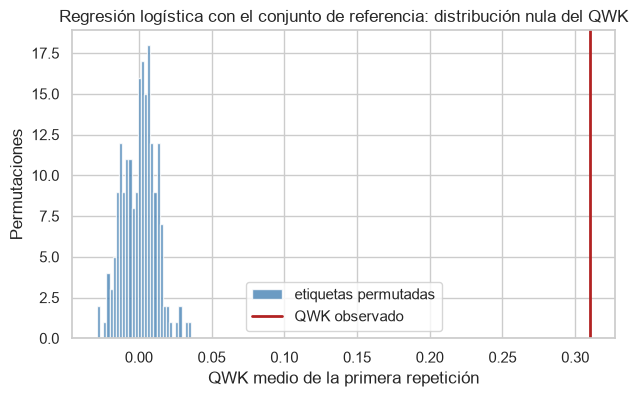

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(qwk_nulo, bins=30, color="steelblue", alpha=0.8, label="etiquetas permutadas")
ax.axvline(qwk_observado, color="firebrick", linewidth=2, label="QWK observado")
ax.set(
    xlabel="QWK medio de la primera repetición",
    ylabel="Permutaciones",
    title="Regresión logística con el conjunto de referencia: distribución nula del QWK",
)
ax.legend()
save_figure(fig, "h1_permutacion_referencia", FIGURAS)
plt.show()

### Conclusión

#### Desempeño del modelo de referencia

Con solo la edad, el sexo y la temporada de inscripción, las dos configuraciones superan con claridad a los controles de la sección 3:

| Métrica | Aleatorio estratificado | Regresión logística | Gradient boosting |
|---|---|---|---|
| QWK | −0,010 ± 0,022 | 0,311 ± 0,004 | 0,302 ± 0,005 |
| Recall ninguno | 0,586 ± 0,011 | 0,646 ± 0,005 | 0,643 ± 0,009 |
| Recall leve | 0,273 ± 0,021 | 0,208 ± 0,013 | 0,235 ± 0,011 |
| Recall moderado | 0,123 ± 0,025 | 0,238 ± 0,011 | 0,211 ± 0,024 |
| Recall severo | 0,006 ± 0,013 | 0,582 ± 0,048 | 0,324 ± 0,072 |
| Subestimación moderado o severo | 0,874 ± 0,022 | 0,387 ± 0,005 | 0,466 ± 0,010 |
| Subestimación severo | 0,994 ± 0,013 | 0,418 ± 0,048 | 0,676 ± 0,072 |

- **QWK.** Las dos configuraciones alcanzan un QWK de alrededor de 0,30, con una diferencia entre ellas de 0,009, del orden de su variación entre repeticiones. Con tres variables, un modelo más flexible no aporta sobre uno lineal.
- **Desempeño por nivel.** La ponderación de las clases desplaza las asignaciones hacia los niveles altos: frente al clasificador aleatorio, el recall aumenta en los niveles moderado y severo, y la subestimación de los participantes con PIU moderado o severo baja de 0,874 a 0,387 con la regresión logística. El costo recae en el nivel leve, cuyo recall queda por debajo del clasificador aleatorio: con la edad y el sexo, el modelo distingue los extremos de la severidad mejor que los niveles intermedios.
- **Nivel severo.** La regresión logística identifica en promedio 0,582 de los casos severos, alrededor de 20 de 34, y gradient boosting 0,324, alrededor de 11. La diferencia es grande frente a su variación entre repeticiones, pero se apoya en 34 participantes, por lo que se toma como una observación preliminar y no como una ventaja establecida de una configuración sobre la otra.

#### Hiperparámetros elegidos y costo

- **Regresión logística.** La intensidad de la regularización elegida varía entre particiones, de C = 0,01 a C = 100, con la mayoría entre 0,1 y 10. Con solo tres predictores, el QWK interno cambia poco con C, por lo que la elección es inestable sin afectar el desempeño.
- **Gradient boosting.** En 19 de las 25 particiones se eligió la combinación más simple, 100 iteraciones y 7 hojas por árbol, coherente con el poco detalle que pueden aportar tres variables.
- **Costo.** El entrenamiento completo, con la búsqueda interna, tomó 6 segundos con la regresión logística y 28 con gradient boosting, lo que hace viables los experimentos de la sección siguiente con los conjuntos de mayor tamaño.

#### Prueba de H1

| Indicador | Valor |
|---|---|
| QWK observado de la regresión logística (primera repetición) | 0,310 |
| QWK con etiquetas permutadas: media | 0,000 |
| QWK con etiquetas permutadas: percentil 95 | 0,016 |
| QWK con etiquetas permutadas: máximo en 200 permutaciones | 0,036 |
| Valor p | 0,005 |

Ninguna de las 200 permutaciones alcanzó un QWK cercano al observado: el máximo fue 0,036, frente a 0,310. El valor p de 0,005 es el mínimo posible con 200 permutaciones, 1/201, de modo que el valor real podría ser aún menor. La figura muestra la distribución nula concentrada alrededor de 0 y el QWK observado muy por encima de ella.

**La hipótesis H1 se sostiene:** el modelo de referencia supera al azar. La edad y el sexo contienen información sobre la severidad del PIU, como anticipaba el análisis exploratorio, y un QWK de alrededor de 0,31 es el desempeño que los conjuntos con variables físicas deben superar para aportar información adicional.